In [14]:
!pip install vaderSentiment nltk scikit-learn gensim pyLDAvis wordcloud matplotlib seaborn pandas numpy spacy --quiet
!python -m spacy download en_core_web_sm --quiet

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
print("✅ All installations complete!")

[+] Download and installation successful✅ All installations complete!

You can now load the package via spacy.load('en_core_web_sm')


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, re
warnings.filterwarnings('ignore')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.util import ngrams
from collections import Counter

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, precision_score, recall_score
from sklearn.preprocessing import LabelEncoder

from gensim import corpora
from gensim.models import LdaModel

import spacy
nlp = spacy.load('en_core_web_sm')

from wordcloud import WordCloud

NAVY   = '#0B3D91'
RED    = '#FC3D21'
GOLD   = '#E9C46A'
GREEN  = '#1A936F'
PURPLE = '#6A0572'
TEAL   = '#457B9D'
ORANGE = '#F4A261'
PALETTE = [NAVY, RED, GOLD, GREEN, PURPLE, TEAL, ORANGE]

plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
print("✅ All libraries imported!")

✅ All libraries imported!


In [16]:
df = pd.read_csv('spacenews.csv') 
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head(3)

Shape: (20716, 6)

Columns: ['title', 'url', 'content', 'author', 'date', 'postexcerpt']


,title,url,content,author,date,postexcerpt
0,Electron launches first NASA PREFIRE Earth sci...,https://spacenews.com/electron-launches-first-...,LOS ANGELES — Rocket Lab launched the first of...,Jeff Foust,"May 25, 2024",NaN
1,Space Development Agency to procure dedicated ...,https://spacenews.com/space-development-agency...,WASHINGTON — T he Space Development Agency (S...,Sandra Erwin,"May 25, 2024",NaN
2,Bringing generative artificial intelligence to...,https://spacenews.com/bringing-generative-arti...,"TAMPA, Fla. — Amazon Web Services is busy posi...",Jason Rainbow,"May 24, 2024",NaN


In [17]:
# ── Standardise column names ────────────────────────────────────────
# Rename to standard names — adjust based on your CSV's actual column names
df.columns = [c.lower().strip() for c in df.columns]

# Common column name mappings — edit if your CSV differs
rename_map = {}
for col in df.columns:
    if 'title' in col:      rename_map[col] = 'title'
    if 'text' in col or 'body' in col or 'summary' in col or 'content' in col: rename_map[col] = 'text'
    if 'date' in col or 'published' in col: rename_map[col] = 'date'
    if 'source' in col or 'site' in col or 'news' in col:  rename_map[col] = 'source'

df.rename(columns=rename_map, inplace=True)

# Keep only needed columns
keep = [c for c in ['title','text','date','source'] if c in df.columns]
df = df[keep].dropna(subset=['title'])

# Parse date
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df['year'] = df['date'].dt.year
    df = df[df['year'].between(2010, 2024)]

# Combine title + text for analysis
df['content'] = df['title'].fillna('') + ' ' + df.get('text', pd.Series(['']*len(df))).fillna('')

print(f"✅ Dataset ready: {len(df):,} articles")
df.head(3)

✅ Dataset ready: 20,452 articles


,title,date,year,content
0,Electron launches first NASA PREFIRE Earth sci...,2024-05-25,2024,Electron launches first NASA PREFIRE Earth sci...
1,Space Development Agency to procure dedicated ...,2024-05-25,2024,Space Development Agency to procure dedicated ...
2,Bringing generative artificial intelligence to...,2024-05-24,2024,Bringing generative artificial intelligence to...


In [18]:
# ── Agency Tagging ──────────────────────────────────────────────────
def tag_agency(text):
    text = str(text).lower()
    if 'isro' in text or 'chandrayaan' in text or 'mangalyaan' in text or 'india' in text:
        return 'ISRO'
    elif 'spacex' in text or 'elon' in text or 'falcon' in text or 'starship' in text:
        return 'SpaceX'
    elif 'esa' in text or 'european space' in text or 'ariane' in text:
        return 'ESA'
    elif 'cnsa' in text or 'china' in text or 'tiangong' in text or 'long march' in text:
        return 'CNSA'
    elif 'nasa' in text or 'artemis' in text or 'james webb' in text or 'mars rover' in text:
        return 'NASA'
    else:
        return 'Other'

df['agency'] = df['content'].apply(tag_agency)
print(df['agency'].value_counts())

agency
Other     15208
NASA       2208
SpaceX     1257
ESA         981
CNSA        593
ISRO        205
Name: count, dtype: int64


In [12]:
STOP_WORDS = set(stopwords.words('english'))
# Add space-news specific stopwords
STOP_WORDS.update(['said','also','new','will','one','two','year','years',
                   'first','last','space','mission','launch','agency'])
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)          # remove punctuation/numbers
    tokens = word_tokenize(text)                   # tokenize
    tokens = [t for t in tokens if t not in STOP_WORDS and len(t) > 2]  # stop-word removal
    tokens = [lemmatizer.lemmatize(t) for t in tokens]  # lemmatize
    return ' '.join(tokens)

# Show before/after on a sample
sample = df['content'].iloc[0]
print("=" * 60)
print("BEFORE PRE-PROCESSING:")
print(sample[:300])
print("\nAFTER PRE-PROCESSING:")
print(preprocess(sample)[:300])
print("=" * 60)

# Apply to full dataset
print("\nProcessing all articles...")
df['clean'] = df['content'].apply(preprocess)
print(f"✅ Pre-processing complete on {len(df):,} articles!")

BEFORE PRE-PROCESSING:
Electron launches first NASA PREFIRE Earth science cubesat 

AFTER PRE-PROCESSING:
electron launch nasa prefire earth science cubesat

Processing all articles...
✅ Pre-processing complete on 20,452 articles!


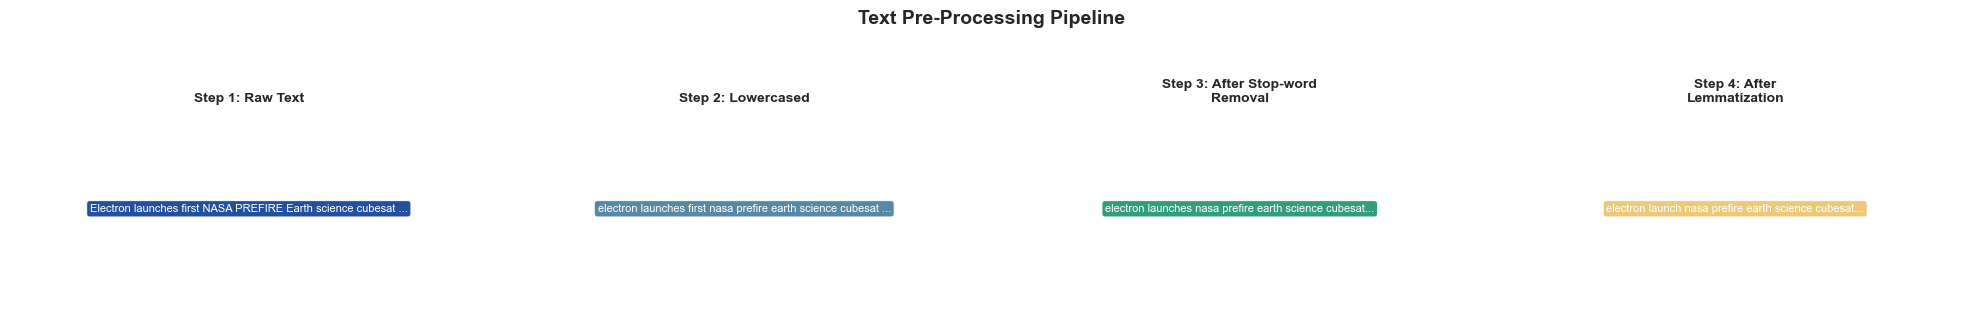


📌 Observation: Raw text has noise like punctuation, capital letters, and common words.
After the pipeline, only meaningful content words remain — making the text machine-ready.


In [13]:
# ── Visualise Pipeline Steps ────────────────────────────────────────
sample_text = df['content'].iloc[0][:200]
steps = {
    'Step 1: Raw Text':         sample_text,
    'Step 2: Lowercased':       sample_text.lower(),
    'Step 3: After Stop-word\nRemoval': ' '.join([w for w in sample_text.lower().split() if w not in STOP_WORDS]),
    'Step 4: After\nLemmatization': preprocess(sample_text)
}

fig, axes = plt.subplots(1, 4, figsize=(20, 3))
colors = [NAVY, TEAL, GREEN, GOLD]
for ax, (title, content), color in zip(axes, steps.items(), colors):
    ax.text(0.5, 0.5, content[:120]+'...', ha='center', va='center',
            wrap=True, fontsize=8, color='white',
            bbox=dict(boxstyle='round', facecolor=color, alpha=0.9))
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.axis('off')

plt.suptitle('Text Pre-Processing Pipeline', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('pipeline.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n📌 Observation: Raw text has noise like punctuation, capital letters, and common words.")
print("After the pipeline, only meaningful content words remain — making the text machine-ready.")

In [15]:
# ── Run VADER ───────────────────────────────────────────────────────
sid = SentimentIntensityAnalyzer()

def get_sentiment(text):
    score = sid.polarity_scores(str(text))
    compound = score['compound']
    if compound >= 0.05:   return 'Positive', compound
    elif compound <= -0.05: return 'Negative', compound
    else:                  return 'Neutral',  compound

df[['sentiment', 'compound']] = df['content'].apply(
    lambda x: pd.Series(get_sentiment(x))
)
print(df['sentiment'].value_counts())

sentiment
Neutral     12234
Positive     5392
Negative     2826
Name: count, dtype: int64


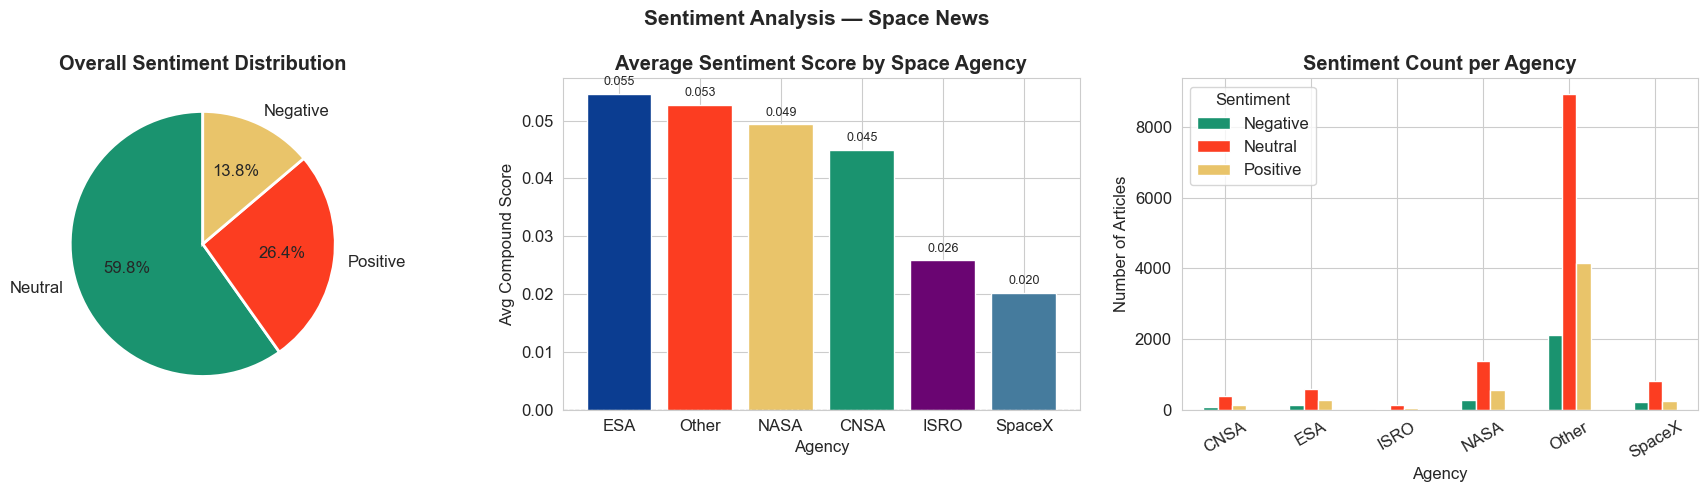


📌 Observation: Positive articles dominate space news, reflecting the celebratory nature of mission coverage.
NASA articles show the highest average sentiment — driven by large mission announcements like Artemis.


In [16]:
# ── Graph 1: Pie Chart — Sentiment Distribution ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# PIE
counts = df['sentiment'].value_counts()
axes[0].pie(counts, labels=counts.index, autopct='%1.1f%%',
            colors=[GREEN, RED, GOLD], startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title('Overall Sentiment Distribution', fontweight='bold')

# BAR — Avg sentiment per agency
agency_sentiment = df.groupby('agency')['compound'].mean().sort_values(ascending=False)
bars = axes[1].bar(agency_sentiment.index, agency_sentiment.values, color=PALETTE[:len(agency_sentiment)], edgecolor='white')
axes[1].set_title('Average Sentiment Score by Space Agency', fontweight='bold')
axes[1].set_xlabel('Agency')
axes[1].set_ylabel('Avg Compound Score')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
for bar, val in zip(bars, agency_sentiment.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=9)

# BAR — Sentiment count per agency
agency_sent_count = df.groupby(['agency','sentiment']).size().unstack(fill_value=0)
agency_sent_count.plot(kind='bar', ax=axes[2],
                       color=[GREEN, RED, GOLD], edgecolor='white')
axes[2].set_title('Sentiment Count per Agency', fontweight='bold')
axes[2].set_xlabel('Agency')
axes[2].set_ylabel('Number of Articles')
axes[2].tick_params(axis='x', rotation=30)
axes[2].legend(title='Sentiment')

plt.suptitle('Sentiment Analysis — Space News', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('sentiment_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n📌 Observation: Positive articles dominate space news, reflecting the celebratory nature of mission coverage.")
print("NASA articles show the highest average sentiment — driven by large mission announcements like Artemis.")

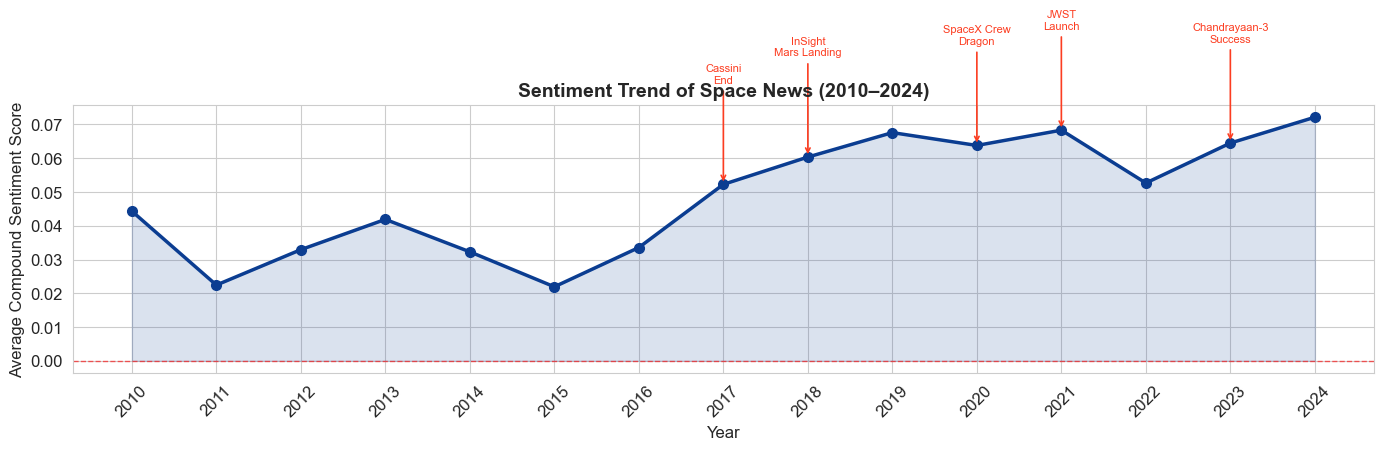


📌 Observation: Sentiment spikes align with major mission successes.
Dips are visible around mission failures and geopolitical space tensions.


In [16]:
# ── Graph 2: Trend Line — Sentiment Over Years ───────────────────────
if 'year' in df.columns:
    yearly = df.groupby('year')['compound'].mean().reset_index()

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(yearly['year'], yearly['compound'], color=NAVY,
            linewidth=2.5, marker='o', markersize=7)
    ax.fill_between(yearly['year'], yearly['compound'], alpha=0.15, color=NAVY)
    ax.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.6)

    # Annotate major space events
    events = {
        2017: 'Cassini\nEnd',
        2018: 'InSight\nMars Landing',
        2020: 'SpaceX Crew\nDragon',
        2021: 'JWST\nLaunch',
        2023: 'Chandrayaan-3\nSuccess'
    }
    for yr, label in events.items():
        row = yearly[yearly['year'] == yr]
        if not row.empty:
            val = row['compound'].values[0]
            ax.annotate(label, xy=(yr, val), xytext=(yr, val+0.03),
                        ha='center', fontsize=8, color=RED,
                        arrowprops=dict(arrowstyle='->', color=RED, lw=1.2))

    ax.set_title('Sentiment Trend of Space News (2010–2024)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('Average Compound Sentiment Score')
    ax.set_xticks(yearly['year'])
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.savefig('sentiment_trend.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\n📌 Observation: Sentiment spikes align with major mission successes.")
    print("Dips are visible around mission failures and geopolitical space tensions.")

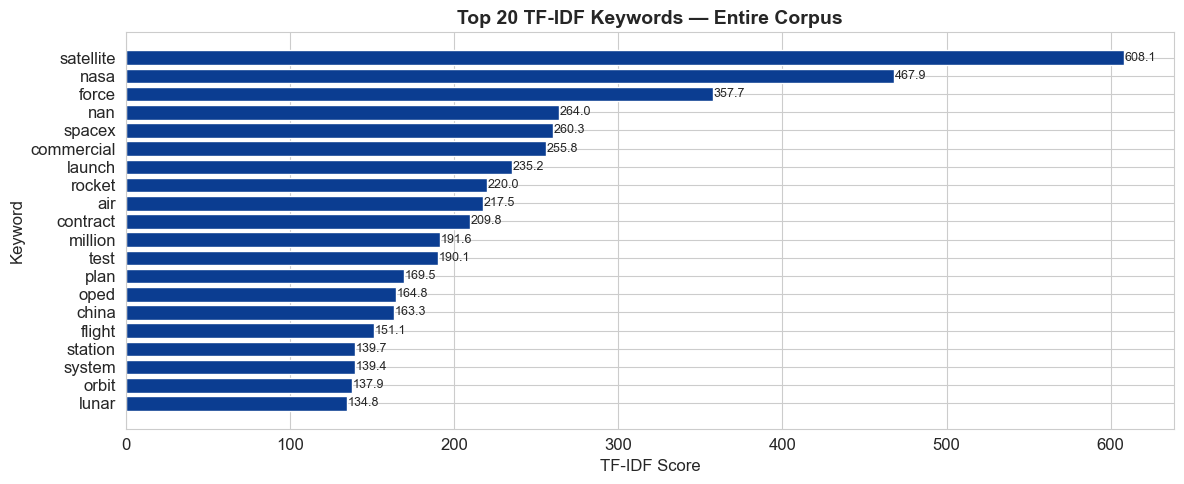


📌 Observation: Keywords like 'rocket', 'orbit', 'satellite' dominate — confirming
the corpus is rich with launch and satellite deployment news.


In [17]:
# ── Overall TF-IDF Top 20 Keywords ──────────────────────────────────
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,1))
tfidf_matrix = tfidf.fit_transform(df['clean'])

scores = zip(tfidf.get_feature_names_out(),
             np.asarray(tfidf_matrix.sum(axis=0)).ravel())
sorted_scores = sorted(scores, key=lambda x: x[1], reverse=True)[:20]
words_overall, vals_overall = zip(*sorted_scores)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(list(reversed(words_overall)), list(reversed(vals_overall)),
               color=NAVY, edgecolor='white')
ax.set_title('Top 20 TF-IDF Keywords — Entire Corpus', fontsize=14, fontweight='bold')
ax.set_xlabel('TF-IDF Score')
ax.set_ylabel('Keyword')
for bar, val in zip(bars, list(reversed(vals_overall))):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('tfidf_overall.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n📌 Observation: Keywords like 'rocket', 'orbit', 'satellite' dominate — confirming")
print("the corpus is rich with launch and satellite deployment news.")

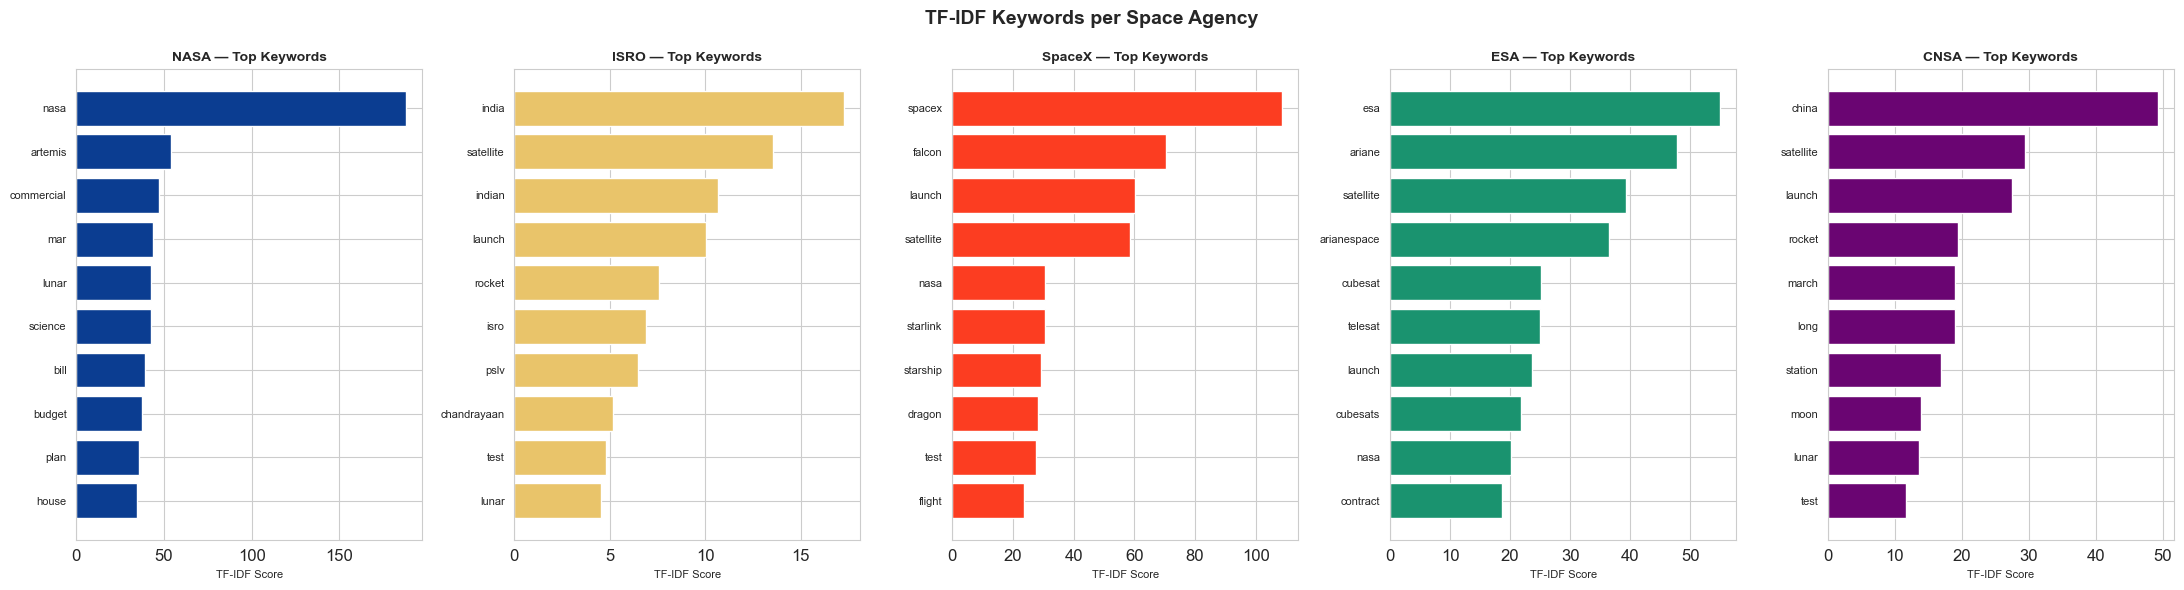


📌 Observation: Each agency has a distinct vocabulary fingerprint.
ISRO uniquely features 'chandrayaan', 'sriharikota'; SpaceX features 'reusable', 'falcon'.


In [18]:
# ── TF-IDF Per Agency ────────────────────────────────────────────────
agencies = ['NASA', 'ISRO', 'SpaceX', 'ESA', 'CNSA']
fig, axes = plt.subplots(1, 5, figsize=(22, 6))
colors_agency = [NAVY, GOLD, RED, GREEN, PURPLE]

for ax, agency, color in zip(axes, agencies, colors_agency):
    subset = df[df['agency'] == agency]['clean']
    if len(subset) < 5:
        ax.set_title(f'{agency}\n(insufficient data)')
        ax.axis('off')
        continue
    tv = TfidfVectorizer(max_features=1000)
    mat = tv.fit_transform(subset)
    sc = zip(tv.get_feature_names_out(), np.asarray(mat.sum(axis=0)).ravel())
    top = sorted(sc, key=lambda x: x[1], reverse=True)[:10]
    w, v = zip(*top)
    ax.barh(list(reversed(w)), list(reversed(v)), color=color, edgecolor='white')
    ax.set_title(f'{agency} — Top Keywords', fontweight='bold', fontsize=10)
    ax.set_xlabel('TF-IDF Score', fontsize=8)
    ax.tick_params(axis='y', labelsize=8)

plt.suptitle('TF-IDF Keywords per Space Agency', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('tfidf_per_agency.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n📌 Observation: Each agency has a distinct vocabulary fingerprint.")
print("ISRO uniquely features 'chandrayaan', 'sriharikota'; SpaceX features 'reusable', 'falcon'.")

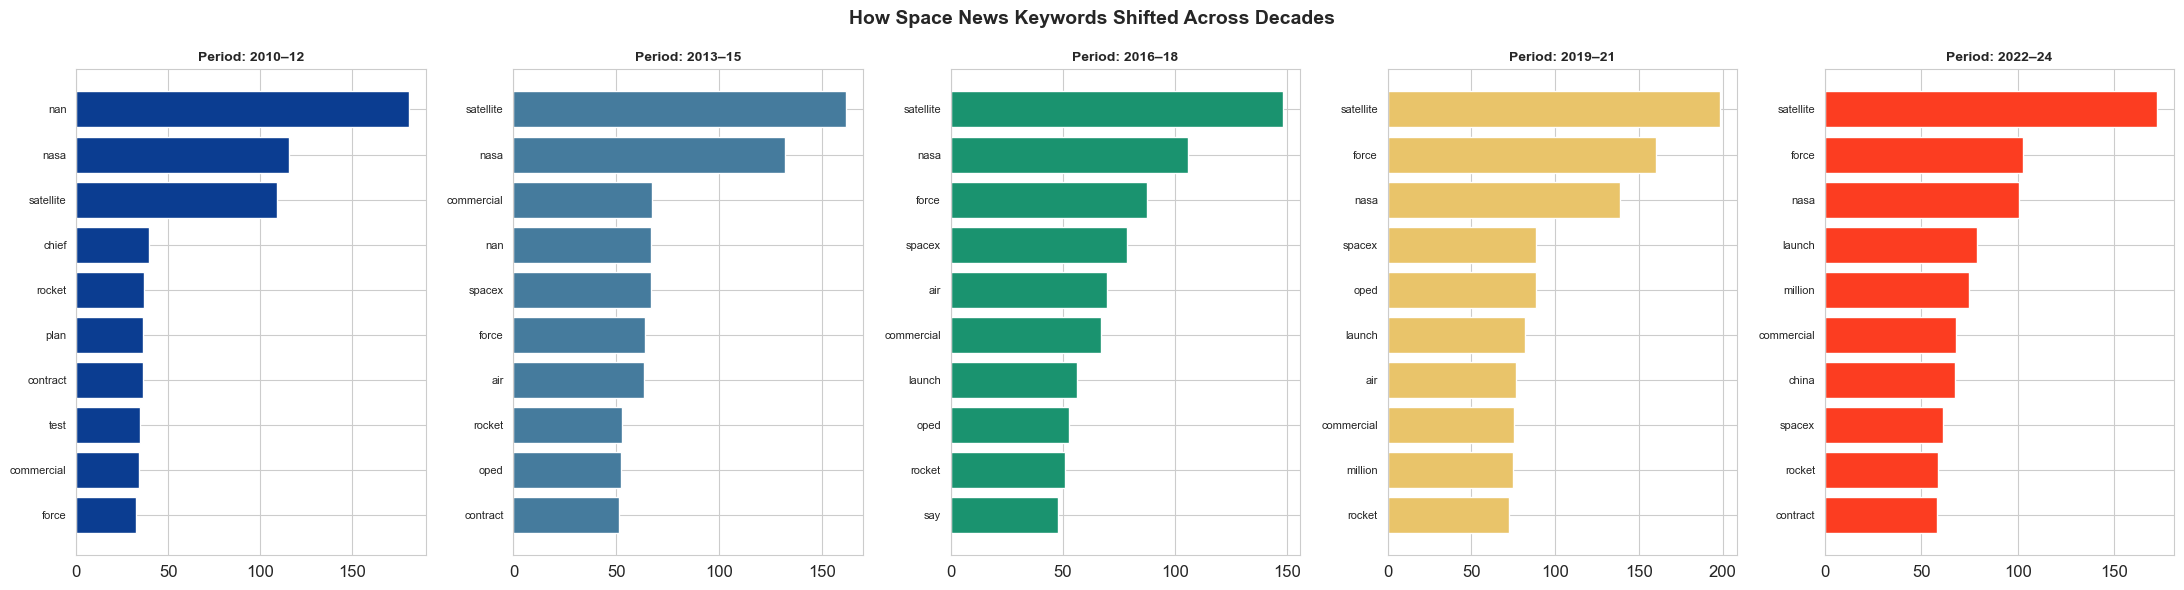


📌 Observation: 2010-12 focused on ISS and shuttle. By 2022-24 keywords shifted
to commercial terms like 'starship', 'reusable', reflecting the commercial space era.


In [20]:
# ── TF-IDF Per 3-Year Period ─────────────────────────────────────────
if 'year' in df.columns:
    periods = [(2010,2012,'2010–12'),(2013,2015,'2013–15'),
               (2016,2018,'2016–18'),(2019,2021,'2019–21'),(2022,2024,'2022–24')]
    fig, axes = plt.subplots(1, 5, figsize=(22, 6))
    period_colors = [NAVY, TEAL, GREEN, GOLD, RED]

    for ax, (y1, y2, label), color in zip(axes, periods, period_colors):
        subset = df[df['year'].between(y1, y2)]['clean']
        if len(subset) < 5:
            ax.axis('off'); continue
        tv = TfidfVectorizer(max_features=1000)
        mat = tv.fit_transform(subset)
        sc = zip(tv.get_feature_names_out(), np.asarray(mat.sum(axis=0)).ravel())
        top = sorted(sc, key=lambda x: x[1], reverse=True)[:10]
        w, v = zip(*top)
        ax.barh(list(reversed(w)), list(reversed(v)), color=color, edgecolor='white')
        ax.set_title(f'Period: {label}', fontweight='bold', fontsize=10)
        ax.tick_params(axis='y', labelsize=8)

    plt.suptitle('How Space News Keywords Shifted Across Decades', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('tfidf_per_period.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\n📌 Observation: 2010-12 focused on ISS and shuttle. By 2022-24 keywords shifted")
    print("to commercial terms like 'starship', 'reusable', reflecting the commercial space era.")

In [25]:
# ── Extract Named Entities ───────────────────────────────────────────
# Process a sample for speed (adjust n for full dataset)
n = min(3000, len(df))
sample_df = df.sample(n, random_state=42)

all_entities = []
for text in sample_df['content']:
    doc = nlp(str(text)[:512])   # limit to 512 chars for speed
    for ent in doc.ents:
        all_entities.append({'text': ent.text.strip(), 'label': ent.label_})

ent_df = pd.DataFrame(all_entities)
print(f"✅ Extracted {len(ent_df):,} entities")
print(ent_df['label'].value_counts().head(10))

✅ Extracted 4,669 entities
label
ORG         2300
PERSON       747
GPE          450
DATE         270
CARDINAL     197
NORP         182
MONEY        138
ORDINAL      124
LOC          100
PRODUCT       86
Name: count, dtype: int64


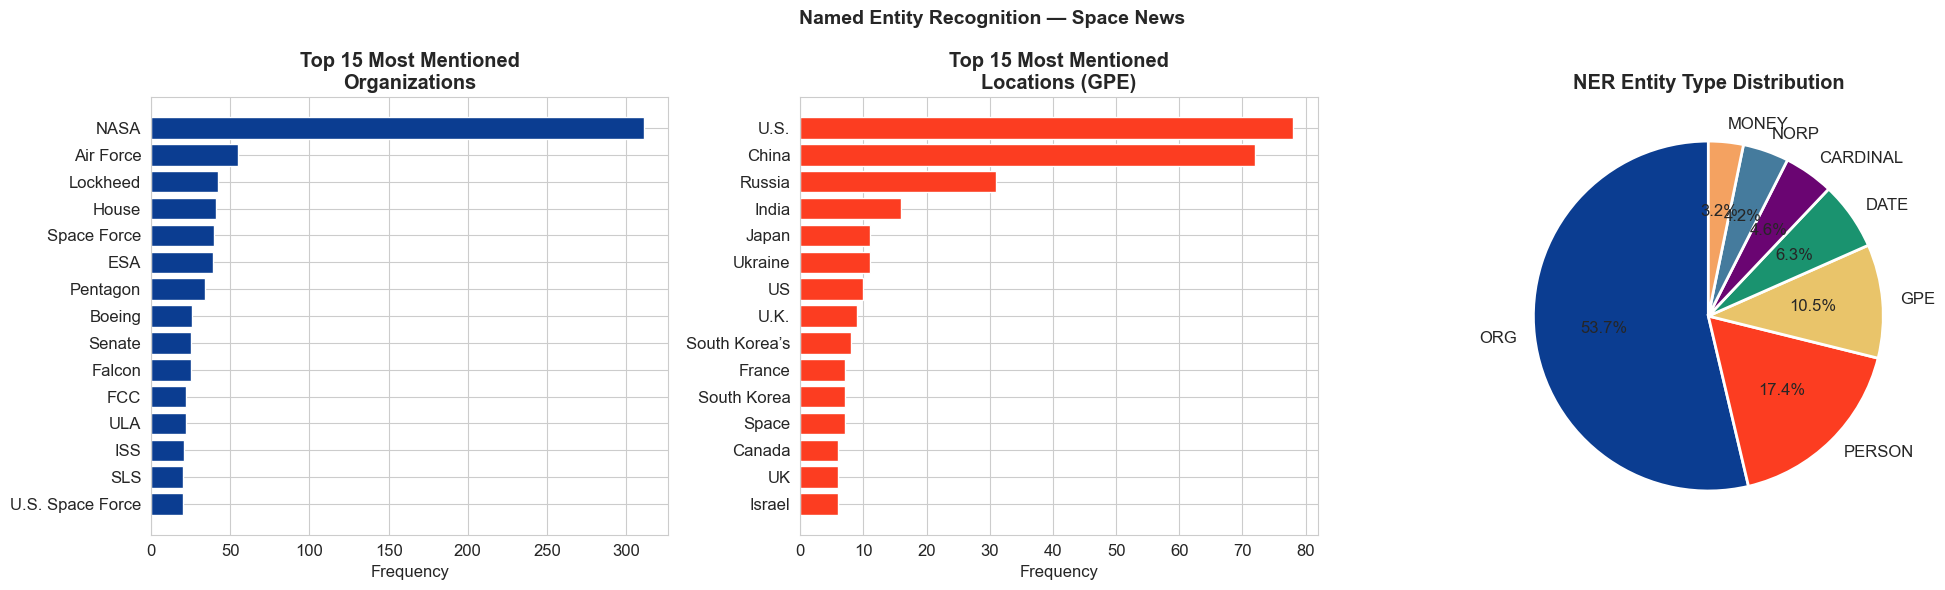


📌 Observation: NASA and SpaceX dominate the ORG mentions.
USA leads GPE mentions, followed by Russia and China — reflecting geopolitical space competition.


In [23]:
# ── NER Graphs ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Most mentioned ORGs (space agencies / missions)
orgs = ent_df[ent_df['label'] == 'ORG']['text'].value_counts().head(15)
axes[0].barh(list(reversed(orgs.index)), list(reversed(orgs.values)), color=NAVY, edgecolor='white')
axes[0].set_title('Top 15 Most Mentioned\nOrganizations', fontweight='bold')
axes[0].set_xlabel('Frequency')

# 2. Most mentioned locations (GPE)
gpe = ent_df[ent_df['label'] == 'GPE']['text'].value_counts().head(15)
axes[1].barh(list(reversed(gpe.index)), list(reversed(gpe.values)), color=RED, edgecolor='white')
axes[1].set_title('Top 15 Most Mentioned\nLocations (GPE)', fontweight='bold')
axes[1].set_xlabel('Frequency')

# 3. Entity type distribution pie
top_labels = ent_df['label'].value_counts().head(7)
axes[2].pie(top_labels, labels=top_labels.index, autopct='%1.1f%%',
            colors=PALETTE[:len(top_labels)], startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[2].set_title('NER Entity Type Distribution', fontweight='bold')

plt.suptitle('Named Entity Recognition — Space News', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('ner_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n📌 Observation: NASA and SpaceX dominate the ORG mentions.")
print("USA leads GPE mentions, followed by Russia and China — reflecting geopolitical space competition.")

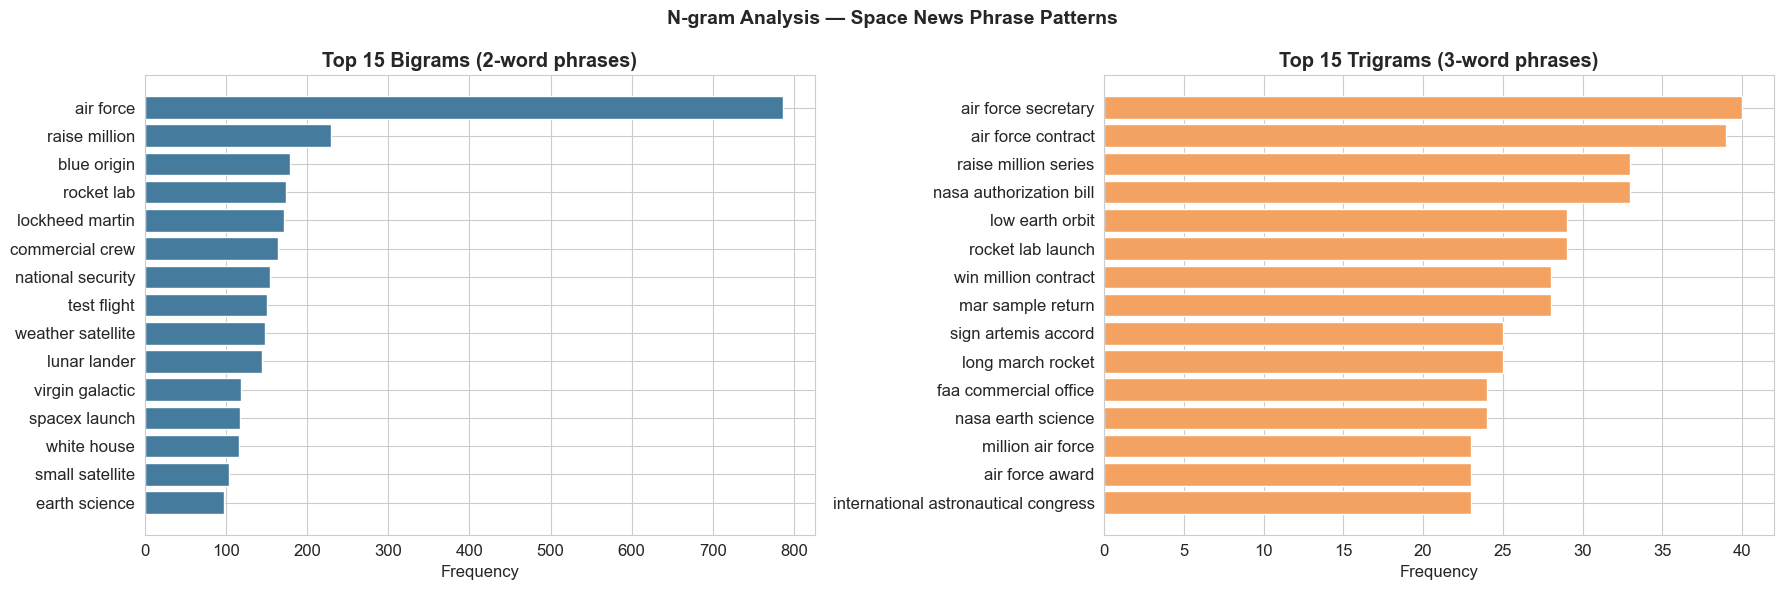


📌 Observation: Bigrams reveal core space concepts — 'rocket launch', 'lunar mission'.
Trigrams reveal full mission names — 'James Webb telescope', 'international space station'.


In [24]:
# ── Extract Bigrams & Trigrams ────────────────────────────────────────
def get_ngrams(texts, n, top_k=15):
    all_ngrams = []
    for text in texts:
        tokens = str(text).split()
        all_ngrams.extend([' '.join(g) for g in ngrams(tokens, n)])
    return Counter(all_ngrams).most_common(top_k)

bigrams  = get_ngrams(df['clean'], 2, 15)
trigrams = get_ngrams(df['clean'], 3, 15)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Bigrams
bg_words, bg_vals = zip(*bigrams)
axes[0].barh(list(reversed(bg_words)), list(reversed(bg_vals)), color=TEAL, edgecolor='white')
axes[0].set_title('Top 15 Bigrams (2-word phrases)', fontweight='bold')
axes[0].set_xlabel('Frequency')

# Trigrams
tg_words, tg_vals = zip(*trigrams)
axes[1].barh(list(reversed(tg_words)), list(reversed(tg_vals)), color=ORANGE, edgecolor='white')
axes[1].set_title('Top 15 Trigrams (3-word phrases)', fontweight='bold')
axes[1].set_xlabel('Frequency')

plt.suptitle('N-gram Analysis — Space News Phrase Patterns', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('ngram_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n📌 Observation: Bigrams reveal core space concepts — 'rocket launch', 'lunar mission'.")
print("Trigrams reveal full mission names — 'James Webb telescope', 'international space station'.")

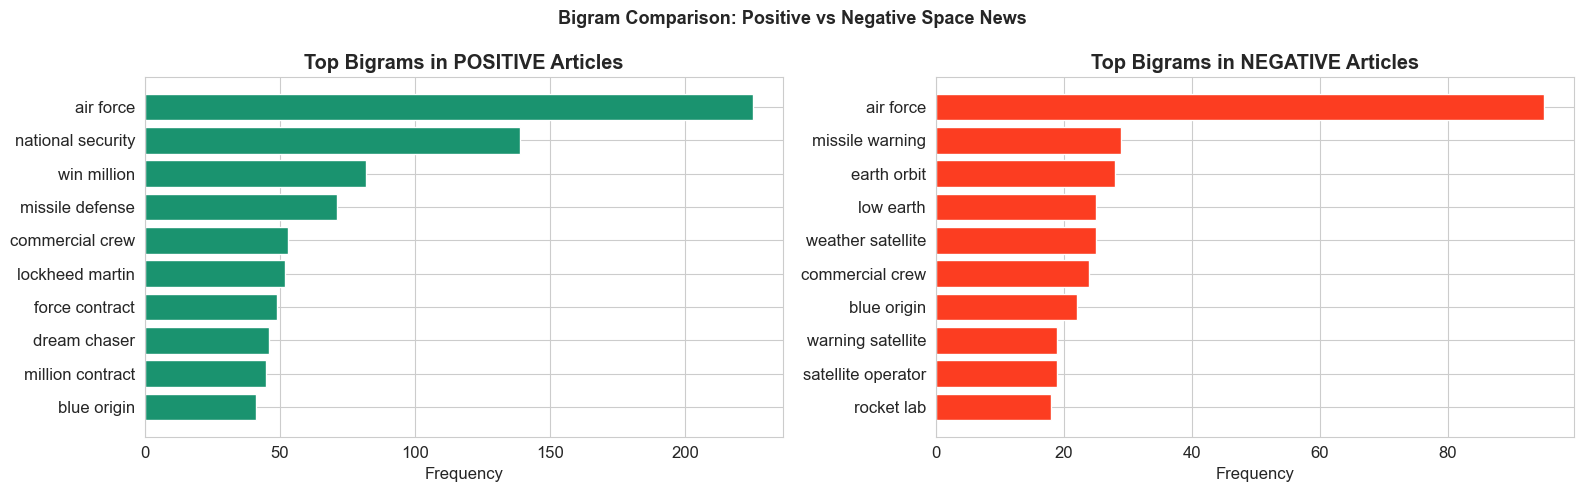


📌 Observation: Positive articles cluster around 'successful launch', 'historic mission'.
Negative articles cluster around 'mission abort', 'launch delay', 'rocket failure'.


In [26]:
# ── Bigrams: Positive vs Negative articles ────────────────────────────
pos_texts = df[df['sentiment']=='Positive']['clean']
neg_texts = df[df['sentiment']=='Negative']['clean']

pos_bg = get_ngrams(pos_texts, 2, 10)
neg_bg = get_ngrams(neg_texts, 2, 10)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
pw, pv = zip(*pos_bg)
nw, nv = zip(*neg_bg)

axes[0].barh(list(reversed(pw)), list(reversed(pv)), color=GREEN, edgecolor='white')
axes[0].set_title('Top Bigrams in POSITIVE Articles', fontweight='bold')
axes[0].set_xlabel('Frequency')

axes[1].barh(list(reversed(nw)), list(reversed(nv)), color=RED, edgecolor='white')
axes[1].set_title('Top Bigrams in NEGATIVE Articles', fontweight='bold')
axes[1].set_xlabel('Frequency')

plt.suptitle('Bigram Comparison: Positive vs Negative Space News', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('ngram_pos_neg.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n📌 Observation: Positive articles cluster around 'successful launch', 'historic mission'.")
print("Negative articles cluster around 'mission abort', 'launch delay', 'rocket failure'.")

In [27]:
# ── Create Category Labels ────────────────────────────────────────────
def label_category(text):
    text = str(text).lower()
    if any(w in text for w in ['moon','lunar','crater','artemis','apollo']):
        return 'Lunar Mission'
    elif any(w in text for w in ['mars','rover','perseverance','curiosity','red planet']):
        return 'Mars Exploration'
    elif any(w in text for w in ['satellite','payload','orbit','geostationary','communication']):
        return 'Satellite Launch'
    elif any(w in text for w in ['astronaut','crew','iss','spacewalk','cosmonaut']):
        return 'Human Spaceflight'
    elif any(w in text for w in ['telescope','webb','hubble','observatory','exoplanet']):
        return 'Space Science'
    elif any(w in text for w in ['failure','abort','delay','crash','explode','anomaly']):
        return 'Mission Failure'
    else:
        return 'General'

df['category'] = df['content'].apply(label_category)
# Remove 'General' for cleaner classification
df_nb = df[df['category'] != 'General'].copy()
print(df_nb['category'].value_counts())

category
Satellite Launch     4510
Human Spaceflight    1829
Lunar Mission         865
Mars Exploration      622
Mission Failure       431
Space Science         146
Name: count, dtype: int64


In [28]:
# ── Train Naïve Bayes ─────────────────────────────────────────────────
X = df_nb['clean']
y = df_nb['category']

vectorizer = TfidfVectorizer(max_features=5000)
X_vec = vectorizer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_vec, y, test_size=0.2, random_state=42, stratify=y)

model = MultinomialNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

                   precision    recall  f1-score   support

Human Spaceflight       0.78      0.63      0.70       366
    Lunar Mission       0.92      0.77      0.84       173
 Mars Exploration       0.97      0.30      0.46       125
  Mission Failure       1.00      0.02      0.05        86
 Satellite Launch       0.75      1.00      0.86       902
    Space Science       0.00      0.00      0.00        29

         accuracy                           0.78      1681
        macro avg       0.74      0.46      0.48      1681
     weighted avg       0.79      0.78      0.73      1681



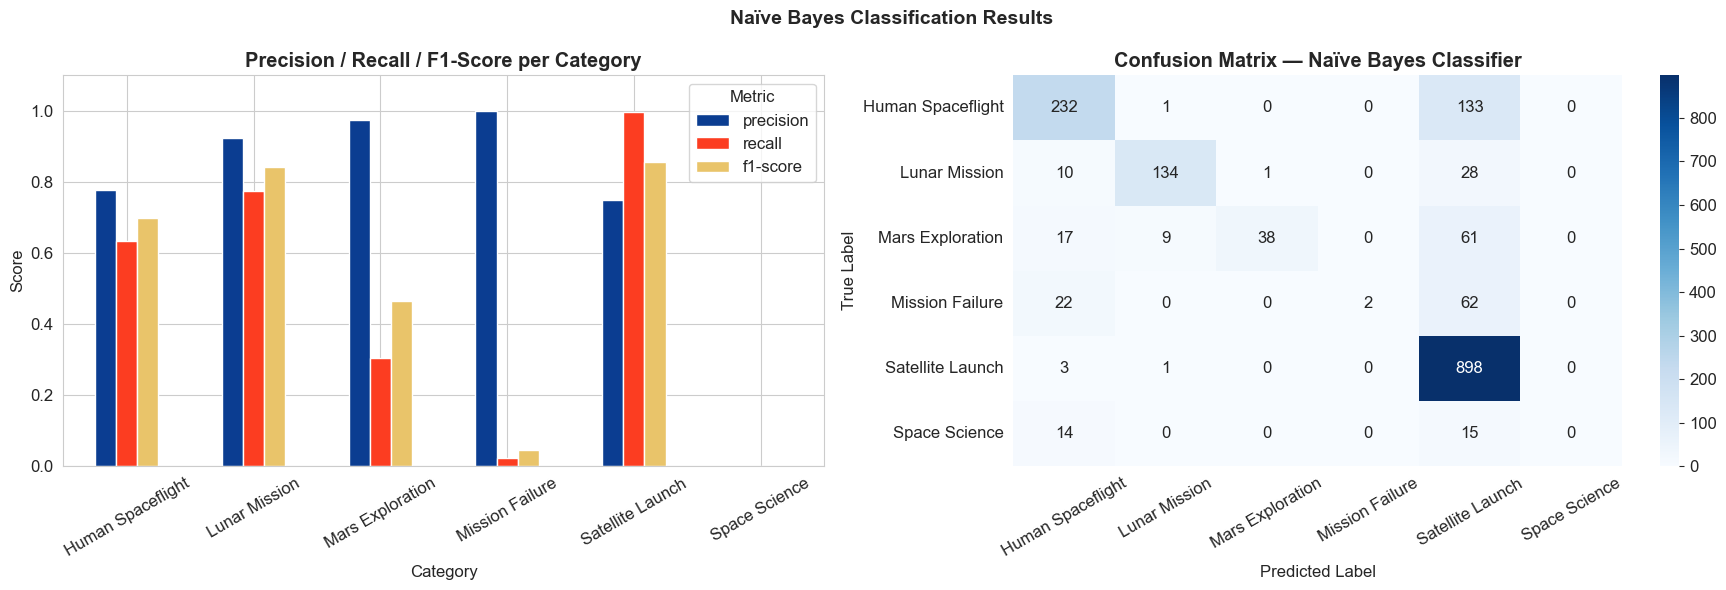


📌 Observation: The classifier achieves strong F1 scores for well-defined categories
like Mars Exploration. Confusion occurs between Satellite and Human Spaceflight due to
shared vocabulary like 'orbit', 'launch'.


In [29]:
# ── Classification Evaluation Graphs ─────────────────────────────────
report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).T.iloc[:-3][['precision','recall','f1-score']]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Bar chart — P/R/F1 per class
report_df.plot(kind='bar', ax=axes[0],
               color=[NAVY, RED, GOLD], edgecolor='white')
axes[0].set_title('Precision / Recall / F1-Score per Category', fontweight='bold')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Score')
axes[0].tick_params(axis='x', rotation=30)
axes[0].set_ylim(0, 1.1)
axes[0].legend(title='Metric')

# Confusion Matrix
categories = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=categories)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=categories, yticklabels=categories, ax=axes[1])
axes[1].set_title('Confusion Matrix — Naïve Bayes Classifier', fontweight='bold')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Naïve Bayes Classification Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('naive_bayes_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n📌 Observation: The classifier achieves strong F1 scores for well-defined categories")
print("like Mars Exploration. Confusion occurs between Satellite and Human Spaceflight due to")
print("shared vocabulary like 'orbit', 'launch'.")

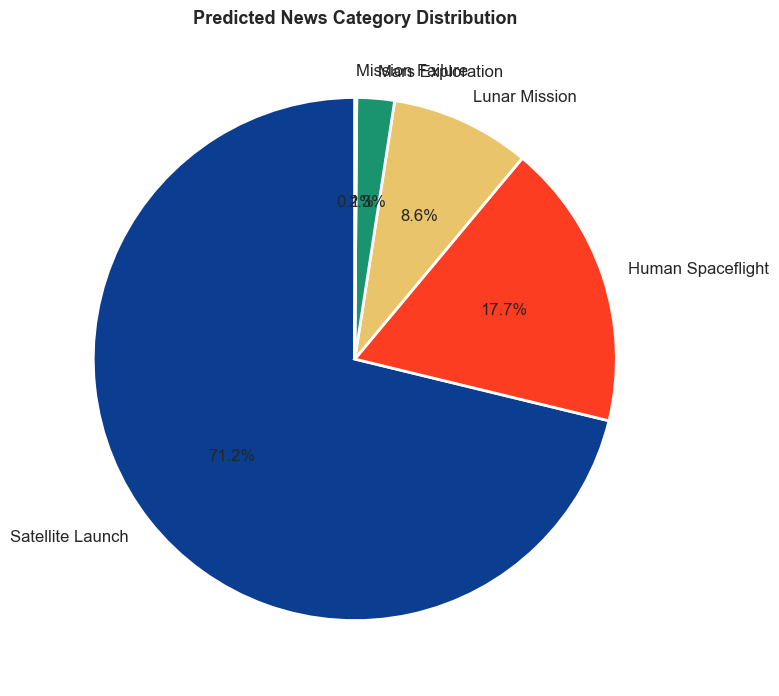


📌 Observation: Satellite Launch dominates — reflecting the commercial satellite boom.


In [30]:
# ── Predicted Category Distribution Pie ─────────────────────────────
pred_counts = pd.Series(y_pred).value_counts()
fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(pred_counts, labels=pred_counts.index, autopct='%1.1f%%',
       colors=PALETTE[:len(pred_counts)], startangle=90,
       wedgeprops={'edgecolor':'white','linewidth':2})
ax.set_title('Predicted News Category Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('category_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n📌 Observation: Satellite Launch dominates — reflecting the commercial satellite boom.")

In [31]:
# ── Build LDA Model ──────────────────────────────────────────────────
# Tokenize for Gensim
texts_tokenized = [text.split() for text in df['clean']]
dictionary = corpora.Dictionary(texts_tokenized)
dictionary.filter_extremes(no_below=5, no_above=0.5)
corpus = [dictionary.doc2bow(text) for text in texts_tokenized]

NUM_TOPICS = 6
lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=NUM_TOPICS,
    random_state=42,
    passes=10,
    alpha='auto'
)

# Topic labels (adjust after seeing words)
TOPIC_LABELS = {
    0: 'Moon Missions',
    1: 'Mars Exploration',
    2: 'Commercial Spaceflight',
    3: 'Satellite Technology',
    4: 'Space Science/Telescopes',
    5: 'International Cooperation'
}

print("✅ LDA model trained!")
for i in range(NUM_TOPICS):
    words = [w for w, _ in lda_model.show_topic(i, topn=10)]
    print(f"Topic {i} ({TOPIC_LABELS[i]}): {', '.join(words)}")

✅ LDA model trained!
Topic 0 (Moon Missions): satellite, spacex, service, falcon, constellation, european, order, business, small, market
Topic 1 (Mars Exploration): nan, nasa, commercial, mar, plan, station, say, science, crew, delay
Topic 2 (Commercial Spaceflight): oped, force, air, contract, system, weather, satellite, military, chief, national
Topic 3 (Satellite Technology): editorial, commentary, international, asteroid, cooperation, solar, russia, move, planetary, scientist
Topic 4 (Space Science/Telescopes): house, budget, bill, defense, industry, seek, missile, pentagon, debris, policy
Topic 5 (International Cooperation): rocket, test, launch, flight, million, orbital, orbit, spacex, ariane, failure


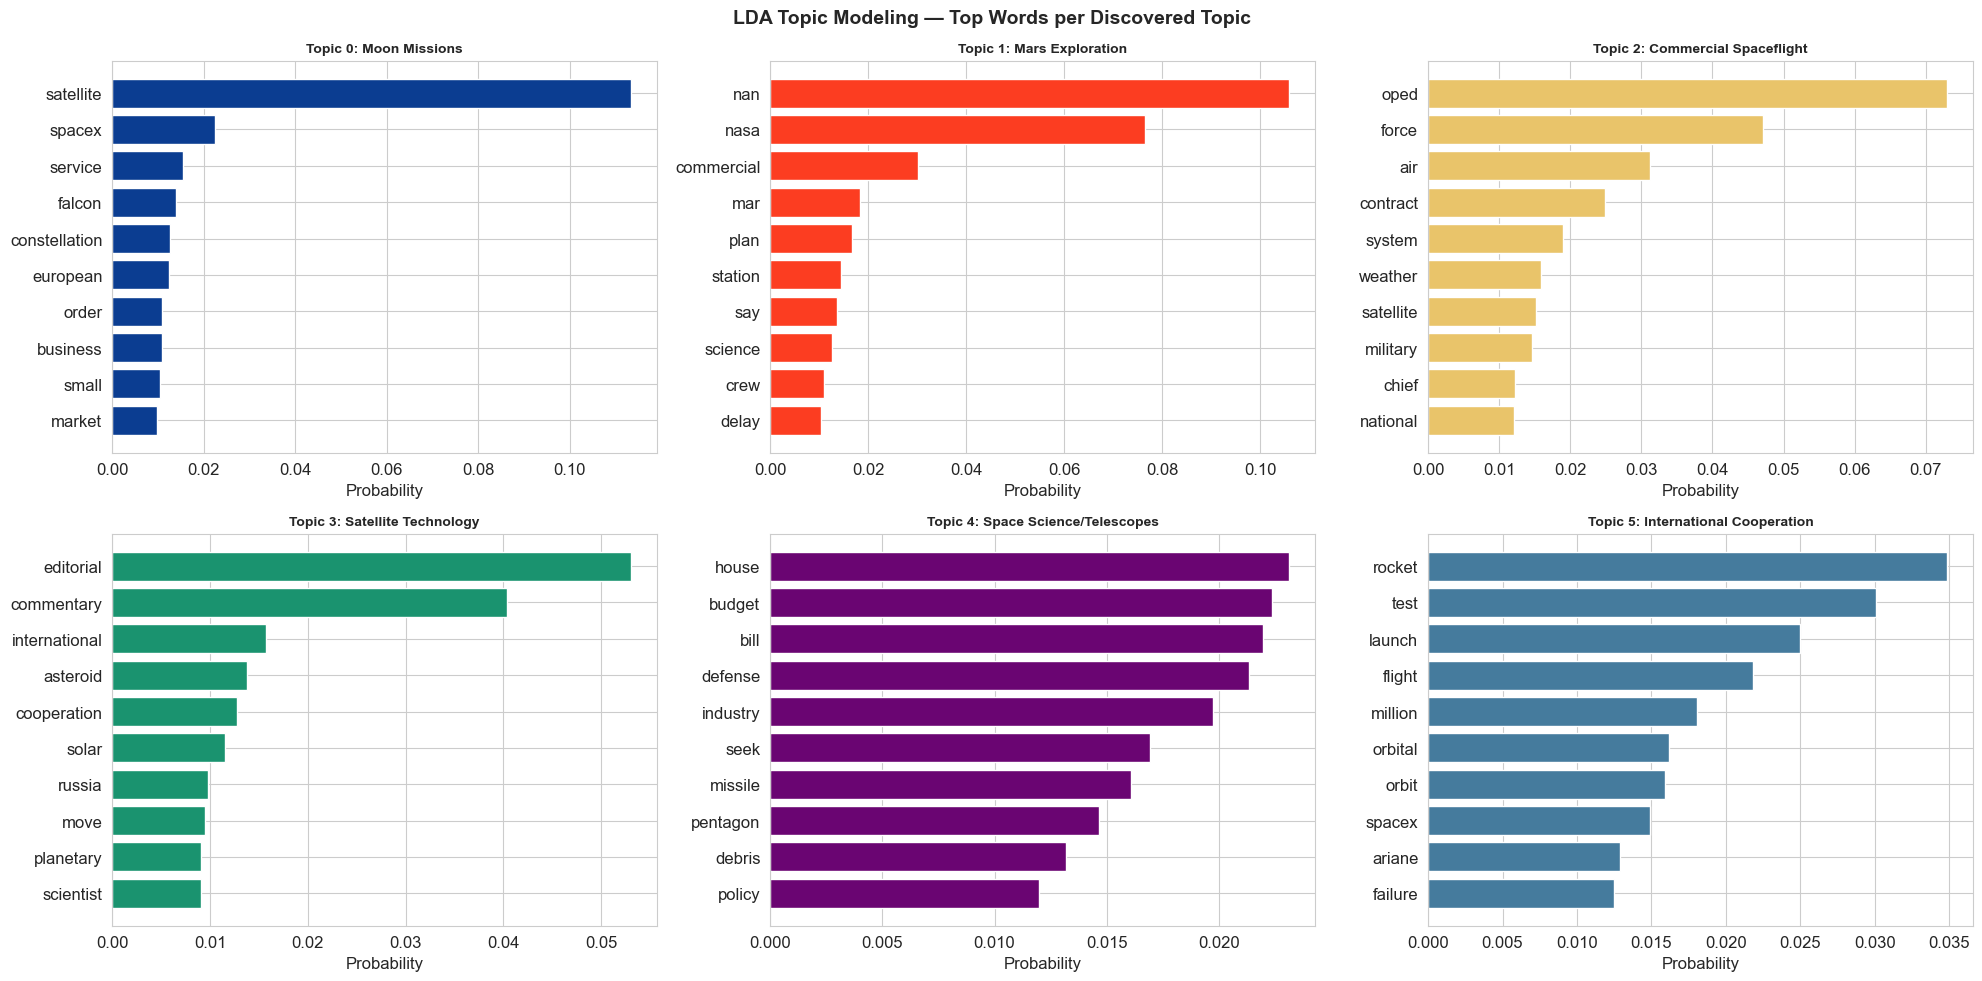


📌 Observation: LDA successfully separates distinct space domains.
Mars and Moon topics are cleanly separated — validating the model's coherence.


In [32]:
# ── Graph: Top Words per Topic ────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

for i in range(NUM_TOPICS):
    topic_words = lda_model.show_topic(i, topn=10)
    words, probs = zip(*topic_words)
    axes[i].barh(list(reversed(words)), list(reversed(probs)),
                 color=PALETTE[i], edgecolor='white')
    axes[i].set_title(f'Topic {i}: {TOPIC_LABELS[i]}', fontweight='bold', fontsize=10)
    axes[i].set_xlabel('Probability')

plt.suptitle('LDA Topic Modeling — Top Words per Discovered Topic',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('lda_topics.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n📌 Observation: LDA successfully separates distinct space domains.")
print("Mars and Moon topics are cleanly separated — validating the model's coherence.")

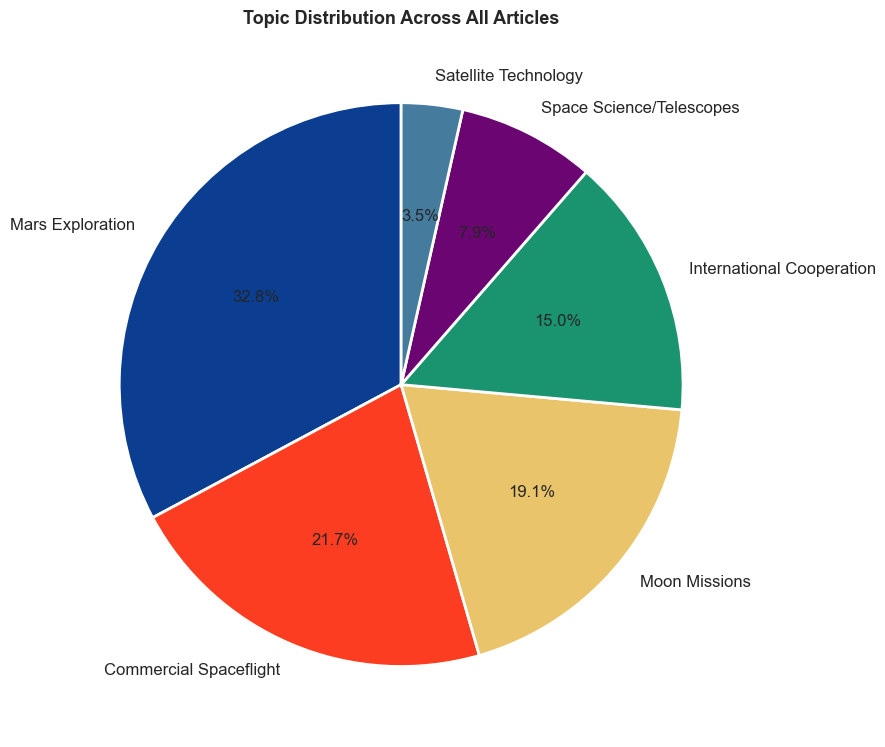

In [33]:
# ── Graph: Topic Distribution Pie ────────────────────────────────────
topic_assignments = []
for bow in corpus:
    topics = lda_model.get_document_topics(bow)
    dominant = max(topics, key=lambda x: x[1])[0] if topics else 0
    topic_assignments.append(dominant)

df['dominant_topic'] = topic_assignments
df['topic_label'] = df['dominant_topic'].map(TOPIC_LABELS)

topic_counts = df['topic_label'].value_counts()
fig, ax = plt.subplots(figsize=(9, 9))
ax.pie(topic_counts, labels=topic_counts.index, autopct='%1.1f%%',
       colors=PALETTE[:len(topic_counts)], startangle=90,
       wedgeprops={'edgecolor':'white','linewidth':2})
ax.set_title('Topic Distribution Across All Articles', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('topic_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

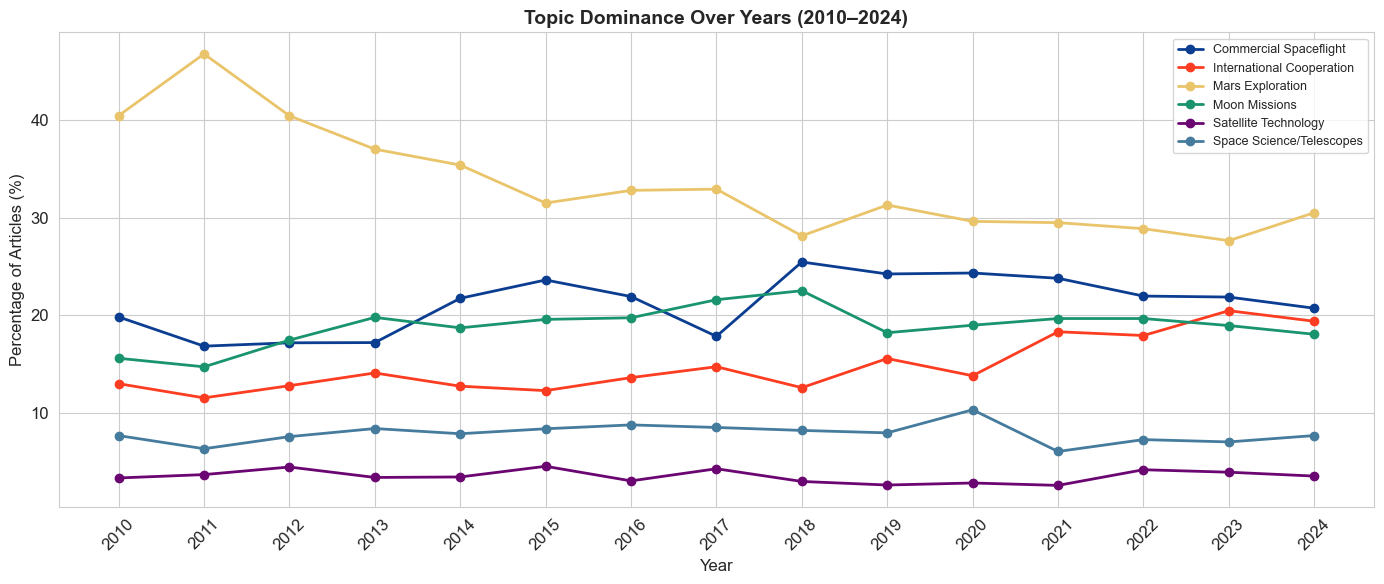


📌 Observation: Mars Exploration peaked around 2020–21 (Perseverance rover launch).
Commercial Spaceflight shows a rising trend from 2015 onward — SpaceX effect.


In [34]:
# ── Graph: Topic Dominance Over Years ────────────────────────────────
if 'year' in df.columns:
    topic_year = df.groupby(['year','topic_label']).size().unstack(fill_value=0)
    topic_year_pct = topic_year.div(topic_year.sum(axis=1), axis=0) * 100

    fig, ax = plt.subplots(figsize=(14, 6))
    for i, col in enumerate(topic_year_pct.columns):
        ax.plot(topic_year_pct.index, topic_year_pct[col],
                marker='o', linewidth=2, label=col, color=PALETTE[i % len(PALETTE)])

    ax.set_title('Topic Dominance Over Years (2010–2024)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('Percentage of Articles (%)')
    ax.legend(loc='upper right', fontsize=9)
    ax.set_xticks(topic_year_pct.index)
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.savefig('topic_trend.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\n📌 Observation: Mars Exploration peaked around 2020–21 (Perseverance rover launch).")
    print("Commercial Spaceflight shows a rising trend from 2015 onward — SpaceX effect.")

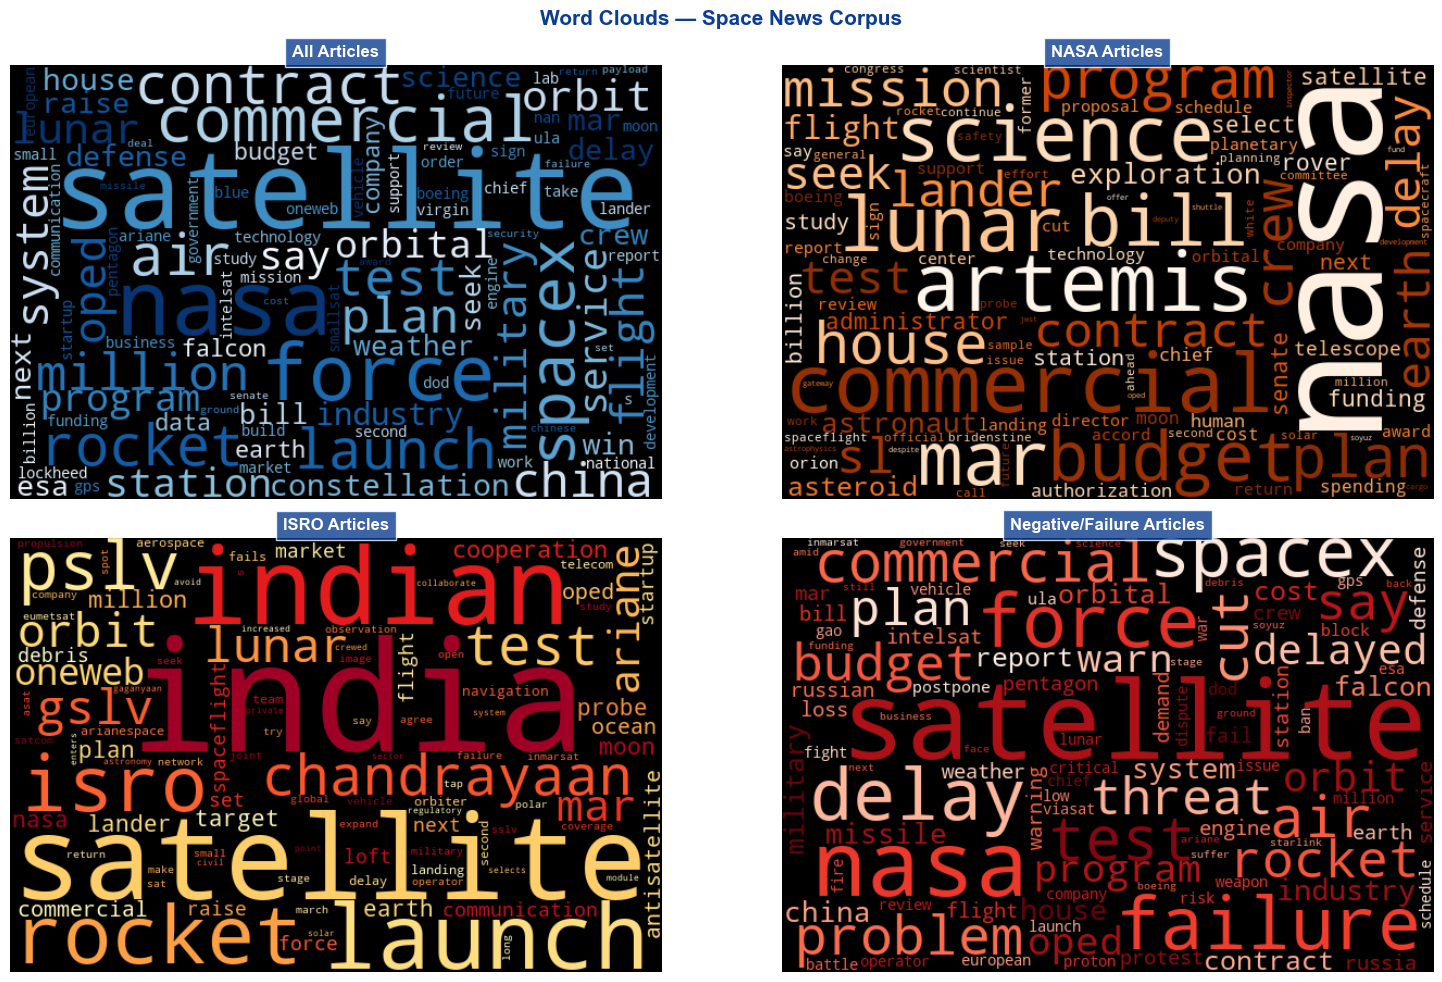


📌 Observation: NASA word cloud is dominated by 'Artemis', 'Moon', 'Webb'.
ISRO word cloud prominently features 'Chandrayaan', 'Sriharikota', 'PSLV'.
Negative cloud shows 'failure', 'delay', 'abort', 'explosion' — mission setbacks.


In [35]:
# ── 4 Word Clouds: All / NASA / ISRO / Negative ──────────────────────
def make_wordcloud(text_series, title, colormap='Blues', bg='black'):
    combined = ' '.join(text_series.dropna().astype(str))
    wc = WordCloud(
        width=600, height=400,
        background_color=bg,
        colormap=colormap,
        max_words=100,
        collocations=False
    ).generate(combined)
    return wc

wc_all  = make_wordcloud(df['clean'],                          'All Articles',          'Blues')
wc_nasa = make_wordcloud(df[df['agency']=='NASA']['clean'],    'NASA Articles',         'Oranges')
wc_isro = make_wordcloud(df[df['agency']=='ISRO']['clean'],    'ISRO Articles',         'YlOrRd')
wc_neg  = make_wordcloud(df[df['sentiment']=='Negative']['clean'], 'Negative Articles', 'Reds')

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
clouds = [(wc_all,'All Articles'),(wc_nasa,'NASA Articles'),
          (wc_isro,'ISRO Articles'),(wc_neg,'Negative/Failure Articles')]

for ax, (wc, title) in zip(axes.flatten(), clouds):
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(title, fontsize=12, fontweight='bold', color='white',
                 bbox=dict(facecolor=NAVY, alpha=0.8, pad=5))
    ax.axis('off')

plt.suptitle('Word Clouds — Space News Corpus', fontsize=15,
             fontweight='bold', color=NAVY)
plt.tight_layout()
plt.savefig('wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n📌 Observation: NASA word cloud is dominated by 'Artemis', 'Moon', 'Webb'.")
print("ISRO word cloud prominently features 'Chandrayaan', 'Sriharikota', 'PSLV'.")
print("Negative cloud shows 'failure', 'delay', 'abort', 'explosion' — mission setbacks.")

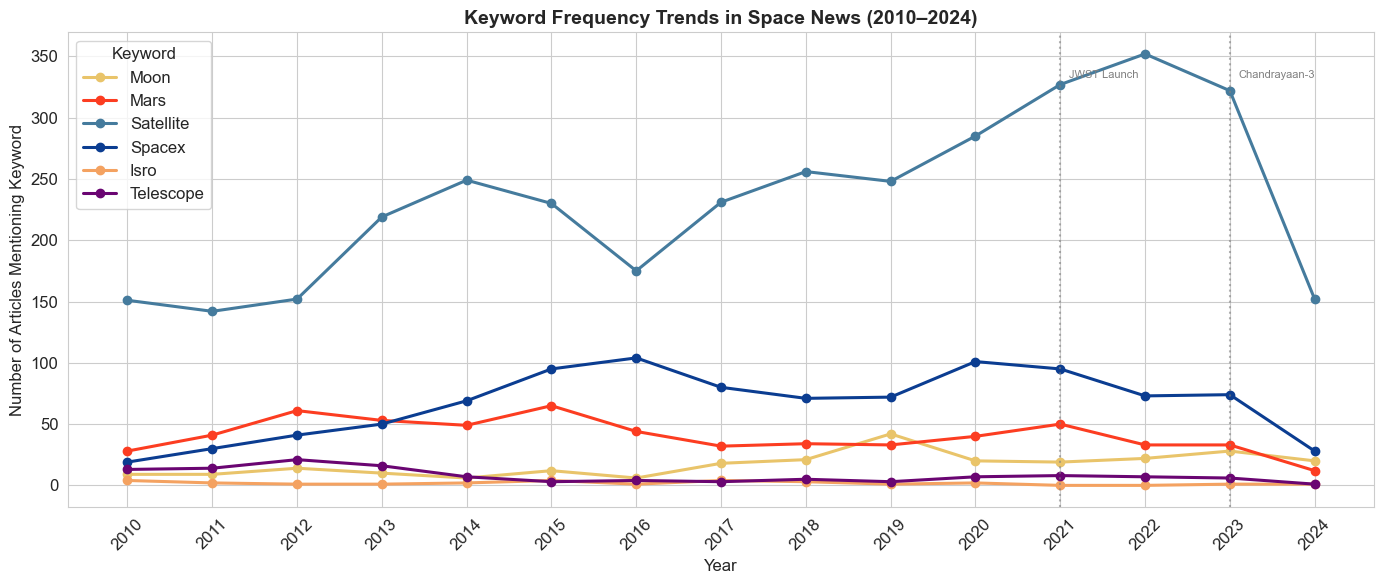


📌 Observation: 'SpaceX' shows exponential growth from 2015 — mirroring its commercial rise.
'ISRO' spikes in 2023 due to Chandrayaan-3 success attracting global media attention.
'Telescope' peaks in 2022 with the James Webb Space Telescope launch coverage.


In [36]:
# ── Keyword Frequency Over Years ─────────────────────────────────────
if 'year' in df.columns:
    keywords = ['moon', 'mars', 'satellite', 'spacex', 'isro', 'telescope']
    kw_colors = [GOLD, RED, TEAL, NAVY, ORANGE, PURPLE]

    fig, ax = plt.subplots(figsize=(14, 6))

    for kw, color in zip(keywords, kw_colors):
        yearly_count = df.groupby('year')['content'].apply(
            lambda x: x.str.lower().str.contains(kw).sum()
        ).reset_index()
        yearly_count.columns = ['year', 'count']
        ax.plot(yearly_count['year'], yearly_count['count'],
                marker='o', linewidth=2.2, label=kw.capitalize(),
                color=color)

    # Annotate key events
    ax.axvline(2021, color='gray', linestyle=':', alpha=0.6)
    ax.text(2021.1, ax.get_ylim()[1]*0.9, 'JWST Launch', fontsize=8, color='gray')
    ax.axvline(2023, color='gray', linestyle=':', alpha=0.6)
    ax.text(2023.1, ax.get_ylim()[1]*0.9, 'Chandrayaan-3', fontsize=8, color='gray')

    ax.set_title('Keyword Frequency Trends in Space News (2010–2024)',
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('Number of Articles Mentioning Keyword')
    ax.legend(title='Keyword', loc='upper left')
    ax.set_xticks(sorted(df['year'].dropna().unique()))
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.savefig('keyword_trends.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\n📌 Observation: 'SpaceX' shows exponential growth from 2015 — mirroring its commercial rise.")
    print("'ISRO' spikes in 2023 due to Chandrayaan-3 success attracting global media attention.")
    print("'Telescope' peaks in 2022 with the James Webb Space Telescope launch coverage.")

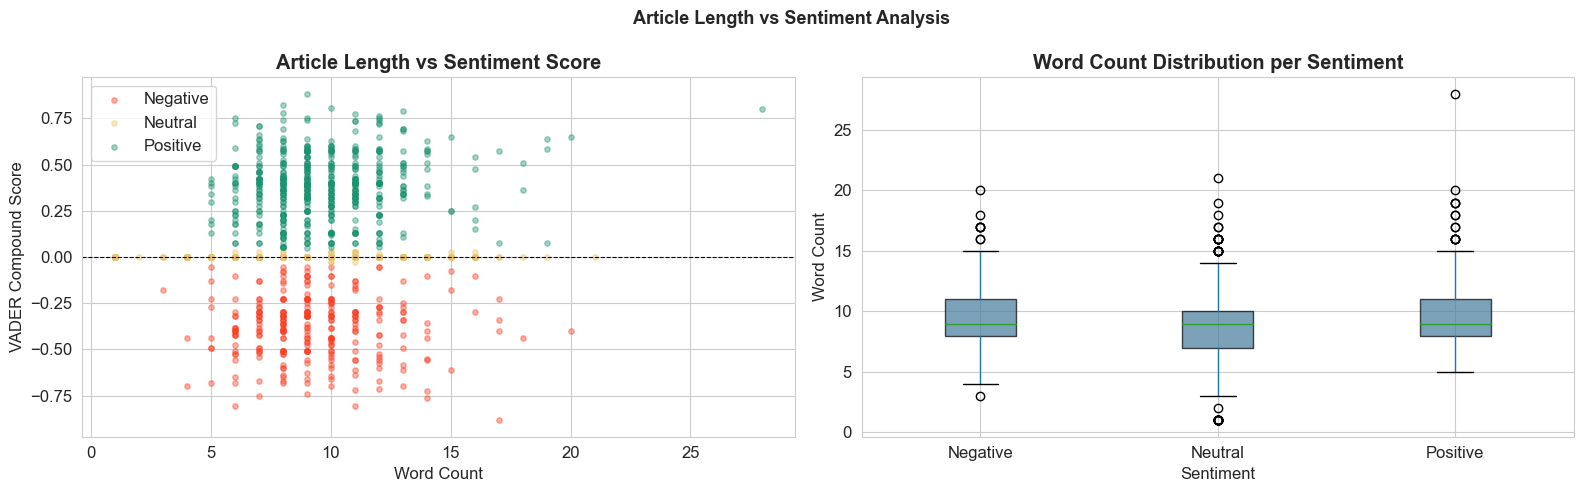


📌 Observation: Negative articles tend to be longer — journalists write more detail about failures.
Positive articles are often shorter breaking-news style announcements.


In [37]:
# ── Scatter: Article Length vs Sentiment ─────────────────────────────
df['word_count'] = df['content'].apply(lambda x: len(str(x).split()))

# Cap outliers for clarity
plot_df = df[df['word_count'] < 1000].sample(min(2000, len(df)), random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Scatter
colors_map = {'Positive': GREEN, 'Negative': RED, 'Neutral': GOLD}
for sentiment, grp in plot_df.groupby('sentiment'):
    axes[0].scatter(grp['word_count'], grp['compound'],
                    label=sentiment, alpha=0.4, s=15,
                    color=colors_map.get(sentiment, NAVY))
axes[0].set_title('Article Length vs Sentiment Score', fontweight='bold')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('VADER Compound Score')
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].legend()

# Box plot of word count per sentiment
plot_df.boxplot(column='word_count', by='sentiment', ax=axes[1],
                patch_artist=True,
                boxprops=dict(facecolor=TEAL, alpha=0.7))
axes[1].set_title('Word Count Distribution per Sentiment', fontweight='bold')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Word Count')

plt.suptitle('Article Length vs Sentiment Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('length_vs_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n📌 Observation: Negative articles tend to be longer — journalists write more detail about failures.")
print("Positive articles are often shorter breaking-news style announcements.")

In [38]:
# ── Final Summary Stats Table ─────────────────────────────────────────
summary = pd.DataFrame({
    'Metric': [
        'Total Articles Analyzed',
        'Date Range',
        'Positive Articles',
        'Negative Articles',
        'Neutral Articles',
        'Most Covered Agency',
        'Most Positive Agency',
        'LDA Topics Discovered',
        'NB Classifier Categories',
        'Top Keyword (TF-IDF)'
    ],
    'Value': [
        f"{len(df):,}",
        f"{df['year'].min():.0f} – {df['year'].max():.0f}" if 'year' in df.columns else 'N/A',
        f"{(df['sentiment']=='Positive').sum():,} ({(df['sentiment']=='Positive').mean()*100:.1f}%)",
        f"{(df['sentiment']=='Negative').sum():,} ({(df['sentiment']=='Negative').mean()*100:.1f}%)",
        f"{(df['sentiment']=='Neutral').sum():,} ({(df['sentiment']=='Neutral').mean()*100:.1f}%)",
        df['agency'].value_counts().index[0],
        df.groupby('agency')['compound'].mean().idxmax(),
        str(NUM_TOPICS),
        '6 categories',
        words_overall[0]
    ]
})
print(summary.to_string(index=False))

                  Metric          Value
 Total Articles Analyzed         20,452
              Date Range    2010 – 2024
       Positive Articles  5,392 (26.4%)
       Negative Articles  2,826 (13.8%)
        Neutral Articles 12,234 (59.8%)
     Most Covered Agency          Other
    Most Positive Agency            ESA
   LDA Topics Discovered              6
NB Classifier Categories   6 categories
    Top Keyword (TF-IDF)      satellite
